In [1]:
]activate ../../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`

In [2]:
using Revise
includet("./base.jl")

In [3]:
using GLMakie
using CairoMakie
CairoMakie.activate!()

In [4]:
BLAS.set_num_threads(1)

# Generate systems, solve ODE, filter and test

In [6]:
K = 10.
l = 0.999
T = 1e8
tol = 1e-9
@time df = solve_si_odes("test1.jld2", 100,
    K, l,
    T, tol,
);
count(df.good), nrow(df)

Progress: 100%|█████████████████████████████████████████| Time: 0:00:40

 40.125563 seconds (4.23 M allocations: 319.622 MiB, 0.42% gc time, 0.02% compilation time: 53% of which was recompilation)

(49, 100)

## Or load previous one

In [5]:
close(f)
df = nothing
GC.gc()

LoadError: UndefVarError: `f` not defined

In [6]:
f = jldopen("./ode_solves.jld2")
f = jldopen("./ode_solves.jld2")
fmd = f["metadata"]

K = fmd.K
l = fmd.l
T = fmd.T
tol = fmd.reltol

Ns = fmd.N

df = f["df"];
count(df.good), nrow(df)

(6256, 10000)

## Test some disprels

Progress: 100%|█████████████████████████████████████████| Time: 0:00:09

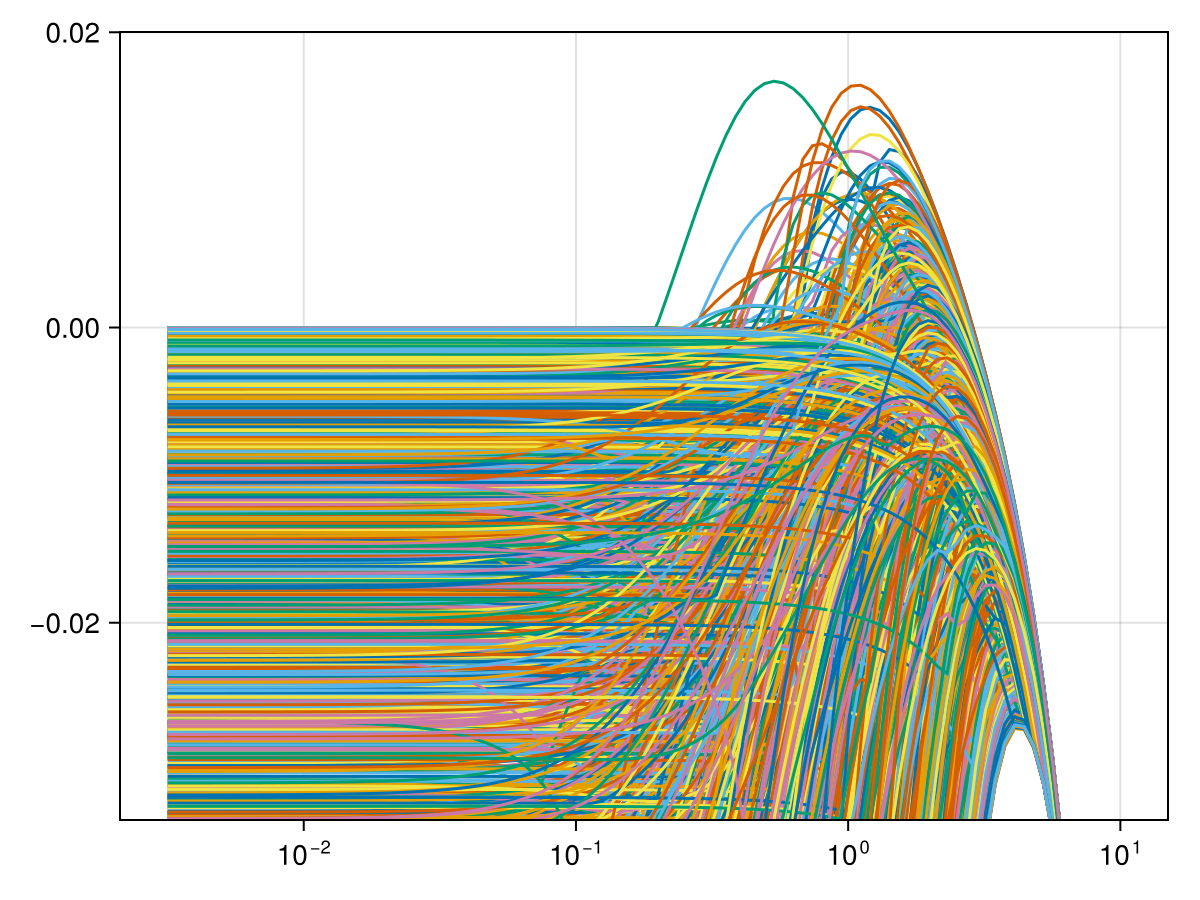

In [11]:
ks = 10 .^ range(-2.5, 1, 100)
DN = 1e-3
p = 1e1
(; Ds, mrls) = si_disprels(df, ks, DN, 1., p);

fig = Figure()
ax = Axis(fig[1,1]; xscale=log10)

for i in 1:nrow(df)
    if df.good[i]
        lines!(ks, mrls[i])
    end
end

mm = abs(maximum(maximum.(mrls[df.good])))
# xlims!(ax, 1e0, 1e2)
ylims!(ax, (-2., 1.2) .* mm)

fig

In [19]:
display(GLMakie.Screen(), fig)

GLMakie.Screen(...)

count((mm->begin
            #= In[23]:1 =#
            maximum(mm) > 0.1
        end), mrls) = 150

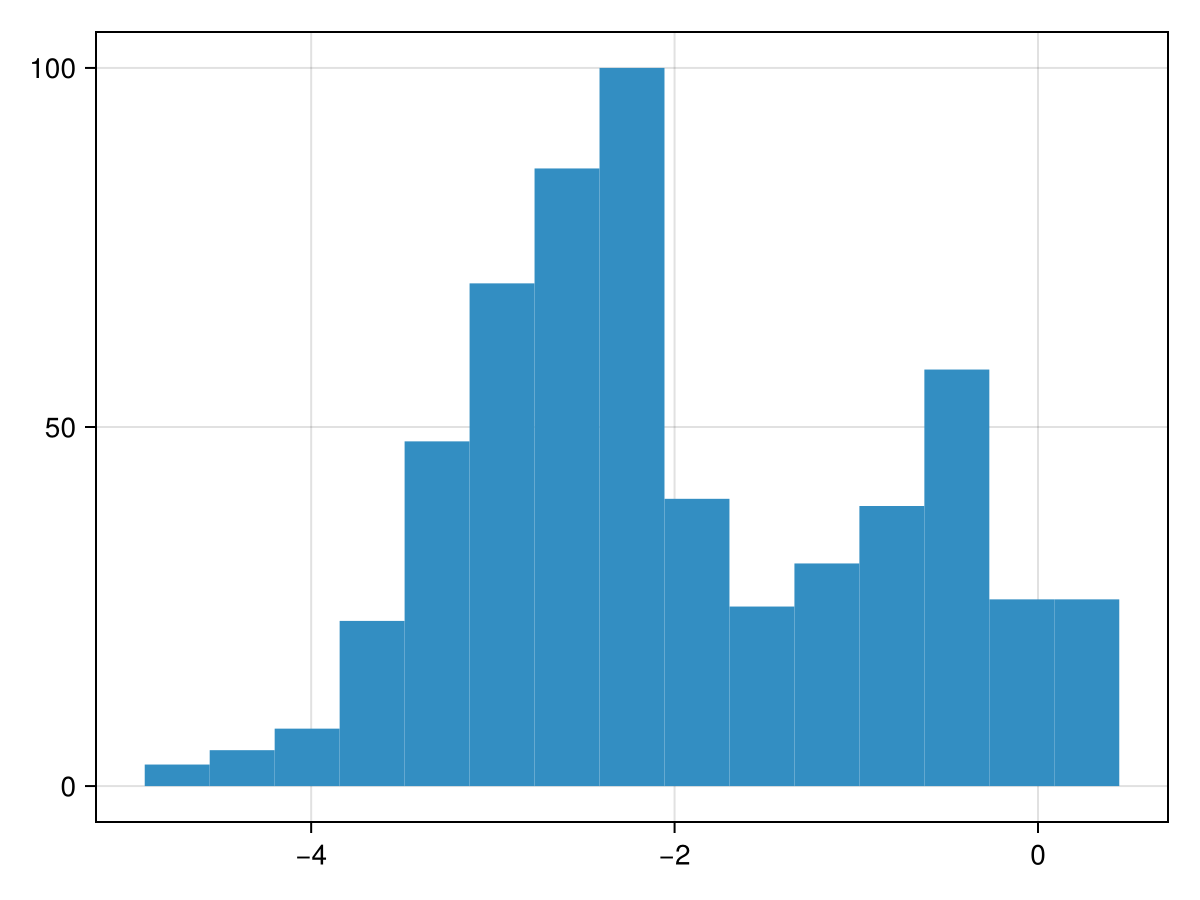

In [23]:
@show count(mm->maximum(mm)>1e-1, mrls)
hist(log10.(filter(>(1e-20), maximum.(mrls))))

# Removing extinct strains

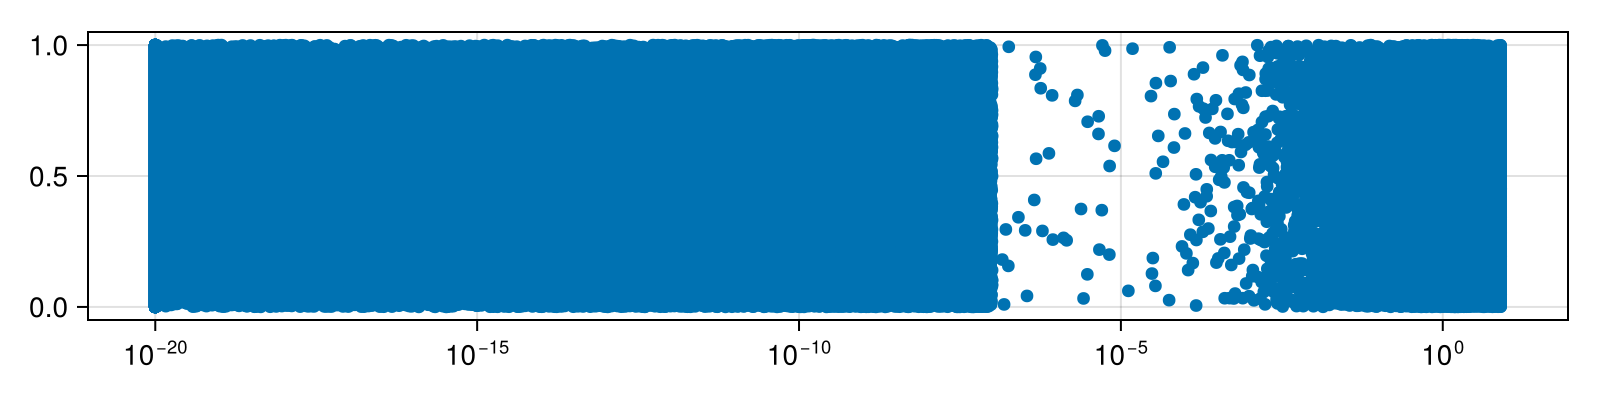

In [20]:
xx = vcat(getindex.(df.final_states, Ref(1:20))...)
scatter(clamp.(xx, 1e-20, Inf), rand(length(xx));
    figure=(;
        size=(800, 200),
    ),
    axis=(;
        xscale=log10,
    ),
)

In [7]:
extinction_threshold = 1e-6

df = df[df.good,[:params,:final_states]]
df.df_row = 1:nrow(df)

for r in eachrow(df)
    xx = reduce_extinct(r.params, r.final_states, extinction_threshold)
    r.params = xx.params
    r.final_states = xx.final_state
end

xx = get_Ns.(df.params)
df.Ns = getindex.(xx, 1)
df.Nr = getindex.(xx, 2);

In [8]:
maxresids = [mmicrmmaxresid(r.final_states, r.params) for r in eachrow(df)]
extrema(maxresids)

(0.0, 9.765933839389618e-9)

# Disprels ps, find a sensible system size and prep for PDE runs

In [52]:
num_systems = 20

# disprels and peak finding
ks = 10 .^ range(-2, 2, 200)  # grid the peak k gets read off, no root finding
ps = [1., 10.]
DN = 1e-3                      # strain diffusion
DI = 1.0                       # influx resource diffusion

# system size and spatial u0
num_peaks = 1.5    # peaks each domain fits; L is set per (system, p) from its own peak k
sN = 250         # spatial gridpoints, same for every run so dx varies with L
epsilon = 1e-2   # uniform, proportional +/- perturbation added to the ODE steady state
seed = 1         # so the u0s can be regenerated
T = T            # PDE end time, same as the ODE T in the section above

out_fname = "systems1_smallL.jld2"

"systems1_smallL.jld2"

In [53]:
(; mrls, peak_ks, peak_hs, at_edge) = disprel_peak_ks(df, ks, DN, DI, ps)

# peaks on the edge of the ks range are not real peaks - widen ks if any turn up
count(at_edge), count(ismissing, peak_ks), length(peak_ks)

(0, 0, 40)

In [54]:
# Drop anything that is not spatially unstable at *every* p. `good` only says the
# well-mixed steady state is stable (that is the k=0 Jacobian), so a good system
# can still have no k>0 instability, and then there is no peak to size a domain
# to. Cutting them here means nothing downstream has to deal with missings.
keep = findall([all(!ismissing, peak_ks[i, :]) for i in 1:nrow(df)])
@show length(keep), nrow(df)
if !isnothing(num_systems)
    keep = keep[sample(1:length(keep), num_systems; replace=false)]
end;

df = df[keep, :]
mrls = mrls[keep, :]
peak_ks = disallowmissing(peak_ks[keep, :])
peak_hs = disallowmissing(peak_hs[keep, :])
at_edge = at_edge[keep, :]
nrow(df)

(length(keep), nrow(df)) = (20, 20)

20

In [55]:
# Band of modes each run's grid can actually carry. L is per (system, p) - sized
# to fit num_peaks peaks of that run's own peak k - and sN is shared, so
# dx = L / sN varies with L too. On a periodic domain the longest wave that fits
# is the domain itself, k = 2pi/L, and the shortest is the Nyquist one at 2dx,
# k = pi/dx. Anything outside [ksmin, ksmax] is invisible to the simulation.
Ls = choose_L.(peak_ks, num_peaks)
dxs = Ls ./ sN

ksmin = 2pi ./ Ls
ksmax = pi ./ dxs

extrema(ksmin), extrema(ksmax)

((0.28317143683579327, 2.2728567131645416), (35.39642960447416, 284.10708914556767))

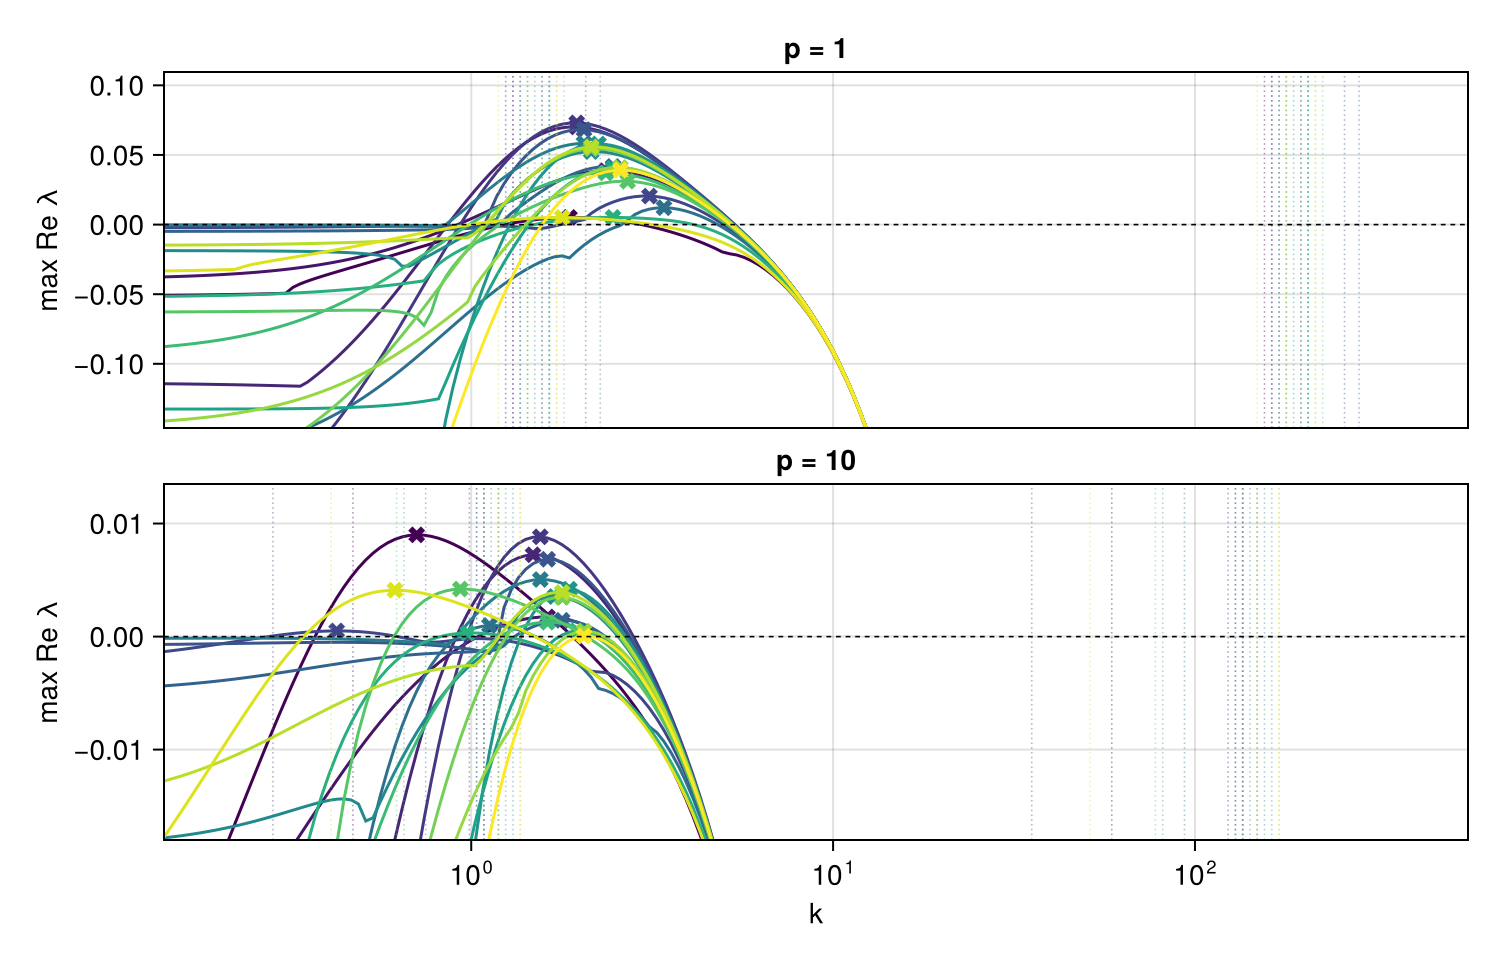

In [56]:
colors = Makie.resample_cmap(:viridis, max(nrow(df), 2))

fig = Figure(; size=(750, 240 * length(ps)))
axs = map(eachindex(ps)) do j
    Axis(fig[j, 1]; xscale=log10, ylabel="max Re λ", title=@sprintf("p = %g", ps[j]))
end
axs[end].xlabel = "k"

for j in eachindex(ps)
    for i in 1:nrow(df)
        lines!(axs[j], ks, mrls[i, j]; color=colors[i])
        scatter!(axs[j], [peak_ks[i, j]], [peak_hs[i, j]];
            color=colors[i], marker=:xcross, markersize=12)
        # the modes this run's grid can carry, [2pi/L, pi/dx]
        vlines!(axs[j], [ksmin[i, j], ksmax[i, j]];
            color=(colors[i], 0.4), linestyle=:dot, linewidth=0.8)
    end
    hlines!(axs[j], 0.0; color=:black, linestyle=:dash, linewidth=0.8)
    mm = maximum(peak_hs[:, j]) # scale each panel by its own tallest peak
    ylims!(axs[j], -2mm, 1.5mm)
end

linkxaxes!(axs...)
# zoom onto where the peaks and the accessible bands are rather than the whole
# scanned range. On all of them, not just the linked one - an axis left on
# autolimits pulls the whole link back out to the full ks range
xlims!.(axs, minimum(ksmin) / 2, maximum(ksmax) * 2)
hidexdecorations!.(axs[1:end-1]; grid=false)
rowgap!(fig.layout, 8)

fig

In [57]:
# One L per (system, p), each sized to fit exactly num_peaks peaks of that
# system's peak k at that p. Every run therefore starts with the same peak count
# and, since sN is shared, the same resolution per peak - only L differs. `Ls`
# comes from the mode-band cell above.
sizes_df = DataFrame(; df_row=df.df_row)
for j in eachindex(ps)
    sizes_df[!, @sprintf("k_p%g", ps[j])] = peak_ks[:, j]
    sizes_df[!, @sprintf("L_p%g", ps[j])] = Ls[:, j]
end
@show nrow(sizes_df)
first(sizes_df, 10)

nrow(sizes_df) = 20

Row,df_row,k_p1,L_p1,k_p10,L_p10
,Int64,Float64,Float64,Float64,Float64
1,5529,1.86791,5.04562,0.706718,13.336
2,6217,2.35429,4.00324,1.62576,5.79717
3,4713,1.9564,4.81741,1.48202,6.35941
4,3963,1.9564,4.81741,1.55223,6.07178
5,2117,3.10787,3.03256,0.424757,22.1886
6,5992,2.04907,4.59953,1.62576,5.79717
7,1201,2.46581,3.82218,1.78343,5.28463
8,1489,3.40929,2.76444,1.12267,8.39498
9,6006,2.04907,4.59953,1.55223,6.07178


In [58]:
Random.seed!(seed)

u0s = map(1:nrow(df)) do i
    Ns, Nr = get_Ns(df.params[i])
    perturb_u0_uniform_prop(Ns, Nr, expand_u0_to_size((sN,), df.final_states[i]), epsilon)
end

@show length(u0s) size(u0s[1])
extrema(Ls ./ sN) # dx range

length(u0s) = 20
size(u0s[1]) = (20, 250)

(0.011057776358336973, 0.08875450684417875)

In [59]:
# One row per (system, p) - everything a PDE run needs bar the tolerances and
# maxtime, which are left to whoever runs it.
sysjs = [(i, j) for i in 1:nrow(df) for j in eachindex(ps)]

pde_df = DataFrame(;
    df_row=[df.df_row[i] for (i, _) in sysjs],  # index into the original df
    sys_i=getindex.(sysjs, 1),                 # index into gdf / u0s
    p=[ps[j] for (_, j) in sysjs],
    params=[df.params[i] for (i, _) in sysjs],
    ode_params=[df.params[i] for (i, _) in sysjs],          # reduced params the hss was solved for
    ode_hss=[df.final_states[i] for (i, _) in sysjs],       # reduced well-mixed steady state
    Ds=[make_si_Ds(df.params[i], DN, DI, ps[j]) for (i, j) in sysjs],
    L=[Ls[i, j] for (i, j) in sysjs],  # sized to num_peaks peaks of this (system, p)
    sN=fill(sN, length(sysjs)),
    T=fill(T, length(sysjs)),
    u0=[u0s[i] for (i, _) in sysjs],  # same array object across a system's ps
    mrls=[mrls[i, j] for (i, j) in sysjs],  # disprel on metadata.ks, handy to look at
)

metadata = (; K, l, ks, ps, DN, DI, num_peaks, sN, epsilon, seed)
jldsave(out_fname; metadata, pde_df)

@show nrow(pde_df) filesize(out_fname) / 1e6
select(pde_df, Not(:params, :ode_params, :ode_hss, :Ds, :u0, :mrls)) # the big columns just spam the output

nrow(pde_df) = 40
filesize(out_fname) / 1.0e6 = 1.194441

Row,df_row,sys_i,p,L,sN,T
,Int64,Int64,Float64,Float64,Int64,Float64
1,5529,1,1.0,5.04562,250,1.0e8
2,5529,1,10.0,13.336,250,1.0e8
3,6217,2,1.0,4.00324,250,1.0e8
4,6217,2,10.0,5.79717,250,1.0e8
5,4713,3,1.0,4.81741,250,1.0e8
6,4713,3,10.0,6.35941,250,1.0e8
7,3963,4,1.0,4.81741,250,1.0e8
8,3963,4,10.0,6.07178,250,1.0e8
9,2117,5,1.0,3.03256,250,1.0e8
